# ICU Infection Prevention Adherence: Descriptive Statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_rater = pd.read_csv('data/icu_adherence_by_rater.csv')
df_items = pd.read_csv('data/icu_adherence_by_item.csv').iloc[:, 1:]

In [3]:
df_rater.head()

,icu_id,icu_type,rater,clabsi_score,cauti_score,vap_score
0,1,General,HeadNurse,88.24,77.62,72.17
1,1,General,Attending,67.45,71.90,57.39
2,2,General,HeadNurse,62.35,82.86,76.52
3,2,General,Attending,60.00,73.81,84.35
4,3,General,HeadNurse,74.90,80.24,72.17


In [4]:
df_rater.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   icu_id        40 non-null     int64  
 1   icu_type      40 non-null     object 
 2   rater         40 non-null     object 
 3   clabsi_score  40 non-null     float64
 4   cauti_score   40 non-null     float64
 5   vap_score     40 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 2.0+ KB


In [5]:
df_items.head()

,item_short_description,icu_1,icu_2,icu_3,icu_4,icu_5,icu_6,icu_7,icu_8,icu_9,...,icu_11,icu_12,icu_13,icu_14,icu_15,icu_16,icu_17,icu_18,icu_19,icu_20
0,cvc_indication_documented,1.0,0.85,1.0,1.0,1.0,0.0,1.0,0.8,1.0,...,1.0,1.0,0.0,0.8,0.9,0.9,1.0,0.95,0.8,0.85
1,cvc_guideline_availability,0.5,0.50,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.5,0.5,0.0,1.00,0.0,0.00
2,cvc_initial_staff_training,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,0.5,0.5,0.5,1.00,1.0,1.00
3,cvc_refresher_training,0.0,0.00,0.5,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,0.5,0.5,0.0,0.00,0.0,0.00
4,cvc_daily_chg_bathing_icu,0.5,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.5,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.00,0.0,0.00


In [6]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   item_short_description  116 non-null    object 
 1   icu_1                   116 non-null    float64
 2   icu_2                   116 non-null    float64
 3   icu_3                   116 non-null    float64
 4   icu_4                   116 non-null    float64
 5   icu_5                   116 non-null    float64
 6   icu_6                   116 non-null    float64
 7   icu_7                   116 non-null    float64
 8   icu_8                   116 non-null    float64
 9   icu_9                   116 non-null    float64
 10  icu_10                  116 non-null    float64
 11  icu_11                  116 non-null    float64
 12  icu_12                  116 non-null    float64
 13  icu_13                  116 non-null    float64
 14  icu_14                  116 non-null    fl

### Averaging Scores Across Raters

In [7]:
df_rater_avg = df_rater.groupby(['icu_id', 'icu_type'])[['clabsi_score', 'cauti_score', 'vap_score']].mean()
df_rater_avg.reset_index(inplace=True)
df_rater_avg

,icu_id,icu_type,clabsi_score,cauti_score,vap_score
0,1,General,77.845,74.760,64.780
1,2,General,61.175,78.335,80.435
2,3,General,73.135,77.740,76.955
3,4,General,79.310,90.715,77.395
4,5,General,70.785,73.215,87.395
5,6,General,69.510,65.240,68.265
6,7,General,69.510,70.240,68.045
7,8,General,70.100,86.670,67.610
8,9,General,64.415,70.950,67.825
9,10,Surgical,88.925,87.020,66.525


## Distribution of ICU Types

In [8]:
df_icu_counts = df_rater_avg['icu_type'].value_counts().reset_index()
df_icu_counts.columns = ['ICU Type', 'Count']

total_icus = df_icu_counts['Count'].sum()
df_icu_counts['Percentage'] = (df_icu_counts['Count'] / total_icus * 100).map('{:.1f}%'.format)

df_icu_counts

,ICU Type,Count,Percentage
0,General,9,45.0%
1,Surgical,8,40.0%
2,Medical,3,15.0%


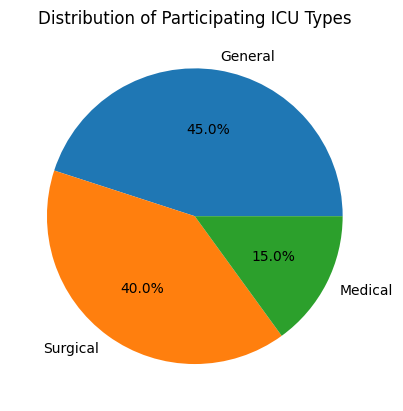

In [9]:
plt.pie(df_icu_counts['Count'], labels=df_icu_counts['ICU Type'], autopct='%1.1f%%')
plt.title('Distribution of Participating ICU Types')
plt.show()

## Adherence Score Statistics by ICU Type

In [10]:
desc_stats = df_rater_avg.groupby('icu_type')[['clabsi_score', 'cauti_score', 'vap_score']].describe()

desc_stats.round(1)

clabsi_score                                           cauti_score  \
                count  mean   std   min   25%   50%   75%   max       count   
icu_type                                                                      
General           9.0  70.6   5.8  61.2  69.5  70.1  73.1  79.3         9.0   
Medical           3.0  80.8  11.2  68.0  76.9  85.8  87.2  88.6         3.0   
Surgical          8.0  86.0  10.8  59.6  88.2  89.7  91.1  91.9         8.0   

                ...             vap_score                                     \
          mean  ...   75%   max     count  mean  std   min   25%   50%   75%   
icu_type        ...                                                            
General   76.4  ...  78.3  90.7       9.0  73.2  7.6  64.8  67.8  68.3  77.4   
Medical   86.0  ...  90.8  91.0       3.0  77.5  8.4  67.8  74.6  81.3  82.3   
Surgical  86.8  ...  88.7  93.9       8.0  72.3  3.7  66.5  71.2  72.8  75.0   

                
           max  
icu_type        
General   87.4  
Medical   83.3  
Surgical  76.3  

[3 rows x 24 columns]

**Interpretation**:
As seen in the table above, adherence rates show clear differences across ICU types.

* Central Line (CLABSI) Preventive Measures: Adherence is highest in Surgical ICUs (mean 86.0%), followed by Medical ICUs (80.8%), and lowest in General ICUs (70.6%).

* Catheter (CAUTI) Preventive Measures: A similar pattern is observed, with Surgical ICUs performing best (mean 86.8%), followed by Medical ICUs (86.0%), and General ICUs (76.4%).

* *Ventilator (VAP) Preventive Measures: The pattern is different here. Medical ICUs show the highest adherence (mean 77.5%), followed by General ICUs (73.2%), and finally Surgical ICUs (72.3%).

## Visualizations of Mean Adherence Rates

### Mean Adherence by ICU and Bundle Type

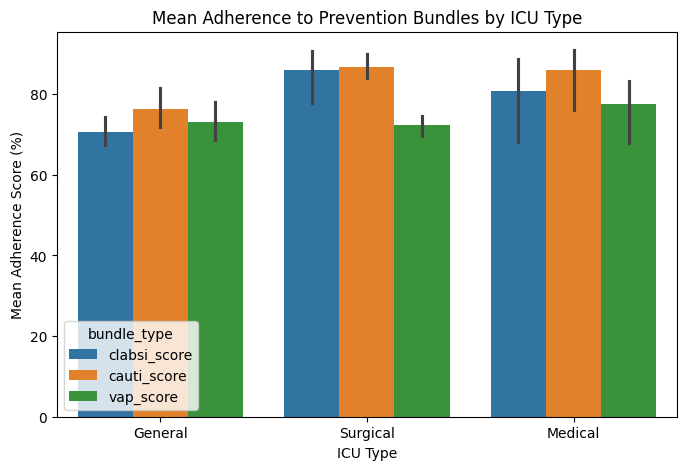

In [11]:
df_melted = pd.melt(
    df_rater_avg,
    id_vars=['icu_type'], 
    value_vars=['clabsi_score', 'cauti_score', 'vap_score'], 
    var_name='bundle_type', 
    value_name='score'
)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_melted, x='icu_type', y='score', hue='bundle_type')

plt.title('Mean Adherence to Prevention Bundles by ICU Type')
plt.ylabel('Mean Adherence Score (%)')
plt.xlabel('ICU Type')
plt.show()

### Granular Adherence by Questionnaire Item

In [12]:
# Calculate mean adherence for each checklist item across all ICUs
item_adherence = df_items.iloc[:, 1:].mean(axis=1)

df_item_adherence = pd.DataFrame({
    'item': df_items['item_short_description'],
    'adherence': item_adherence
})

df_item_adherence

,item,adherence
0,cvc_indication_documented,0.8425
1,cvc_guideline_availability,0.7000
2,cvc_initial_staff_training,0.8750
3,cvc_refresher_training,0.5250
4,cvc_daily_chg_bathing_icu,0.1250
...,...,...
111,vap_avoid_silver_coated_ett,0.9500
112,vap_avoid_kinetic_beds,0.7000
113,vap_avoid_prone_positioning_routine,0.9250
114,vap_avoid_grv_monitoring,0.5750


### Top and Bottom 10 Adherence Practices

C:\Users\Mike\AppData\Local\Temp\ipykernel_8556\4239900695.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=top_10_items, x='adherence', y='item', palette='Greens_r')
C:\Users\Mike\AppData\Local\Temp\ipykernel_8556\4239900695.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=bottom_10_items, x='adherence', y='item', palette='Reds_r')


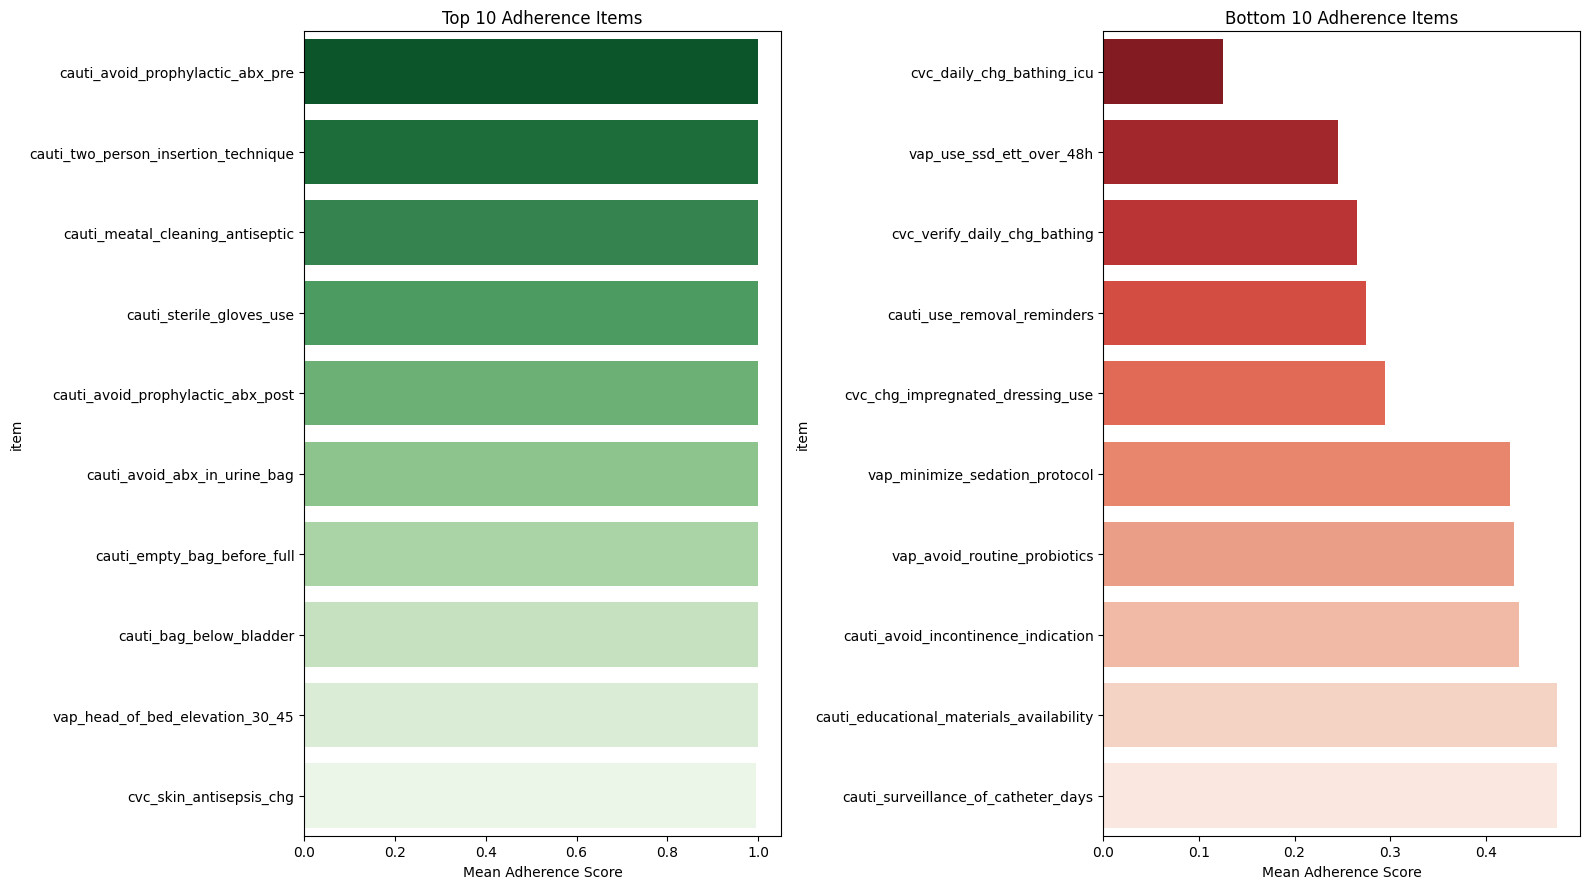

In [13]:
top_10_items = df_item_adherence.sort_values(by='adherence', ascending=False).head(10)
bottom_10_items = df_item_adherence.sort_values(by='adherence', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Plot for Top 10
sns.barplot(ax=axes[0], data=top_10_items, x='adherence', y='item', palette='Greens_r')
axes[0].set_title('Top 10 Adherence Items')
axes[0].set_xlabel('Mean Adherence Score')

# Plot for Bottom 10
sns.barplot(ax=axes[1], data=bottom_10_items, x='adherence', y='item', palette='Reds_r')
axes[1].set_title('Bottom 10 Adherence Items')
axes[1].set_xlabel('Mean Adherence Score')

plt.tight_layout()
plt.show()